In [1]:
import pandas as pd
import numpy as np
df=pd.read_csv(r"C:\Users\Atharva\Downloads\archive (1)\powerconsumption.csv")

In [2]:
df[['GeneralDiffuseFlows','DiffuseFlows']].describe()

,GeneralDiffuseFlows,DiffuseFlows
count,52416.000000,52416.000000
mean,182.696614,75.028022
std,264.400960,124.210949
min,0.004000,0.011000
25%,0.062000,0.122000
50%,5.035500,4.456000
75%,319.600000,101.000000
max,1163.000000,936.000000


In [3]:
df['WindSpeed'].describe()

count    52416.000000
mean         1.959489
std          2.348862
min          0.050000
25%          0.078000
50%          0.086000
75%          4.915000
max          6.483000
Name: WindSpeed, dtype: float64

In [4]:
df['PowerConsumption_Zone1'].describe()

count    52416.000000
mean     32344.970564
std       7130.562564
min      13895.696200
25%      26310.668692
50%      32265.920340
75%      37309.018185
max      52204.395120
Name: PowerConsumption_Zone1, dtype: float64

In [5]:
df['Temperature'].describe()

count    52416.000000
mean        18.810024
std          5.815476
min          3.247000
25%         14.410000
50%         18.780000
75%         22.890000
max         40.010000
Name: Temperature, dtype: float64

In [2]:
df.head()

,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
0,2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [3]:
df.isnull().sum()

Datetime                  0
Temperature               0
Humidity                  0
WindSpeed                 0
GeneralDiffuseFlows       0
DiffuseFlows              0
PowerConsumption_Zone1    0
PowerConsumption_Zone2    0
PowerConsumption_Zone3    0
dtype: int64

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Datetime                52416 non-null  str    
 1   Temperature             52416 non-null  float64
 2   Humidity                52416 non-null  float64
 3   WindSpeed               52416 non-null  float64
 4   GeneralDiffuseFlows     52416 non-null  float64
 5   DiffuseFlows            52416 non-null  float64
 6   PowerConsumption_Zone1  52416 non-null  float64
 7   PowerConsumption_Zone2  52416 non-null  float64
 8   PowerConsumption_Zone3  52416 non-null  float64
dtypes: float64(8), str(1)
memory usage: 4.5 MB


In [5]:
df.describe

<bound method NDFrame.describe of                   Datetime  Temperature  Humidity  WindSpeed  \
0      2017-01-01 00:00:00        6.559      73.8      0.083   
1      2017-01-01 00:10:00        6.414      74.5      0.083   
2      2017-01-01 00:20:00        6.313      74.5      0.080   
3      2017-01-01 00:30:00        6.121      75.0      0.083   
4      2017-01-01 00:40:00        5.921      75.7      0.081   
...                    ...          ...       ...        ...   
52411  2017-12-30 23:10:00        7.010      72.4      0.080   
52412  2017-12-30 23:20:00        6.947      72.6      0.082   
52413  2017-12-30 23:30:00        6.900      72.8      0.086   
52414  2017-12-30 23:40:00        6.758      73.0      0.080   
52415  2017-12-30 23:50:00        6.580      74.1      0.081   

       GeneralDiffuseFlows  DiffuseFlows  PowerConsumption_Zone1  \
0                    0.051         0.119             34055.69620   
1                    0.070         0.085             29814.68

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.shape

(52416, 9)

In [8]:
corr=df.corr(numeric_only=True)

<Axes: >

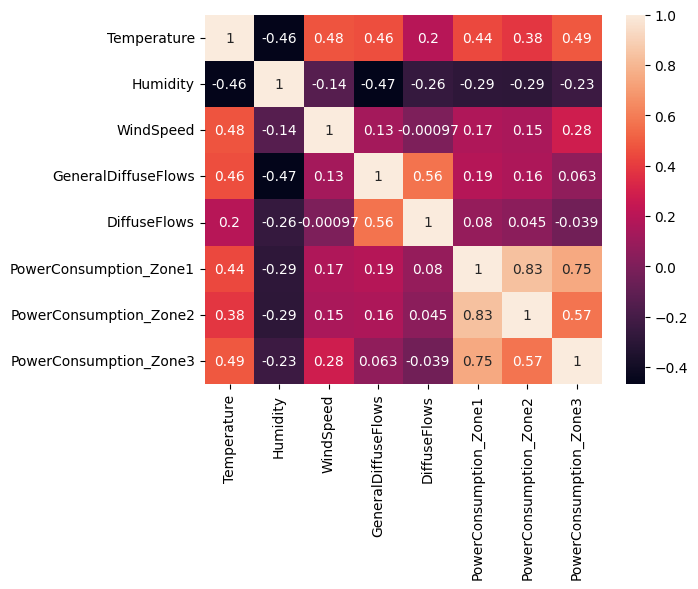

In [9]:
import seaborn as sns
sns.heatmap(corr,annot=True,fmt=".2g")

## We are taking target column as power consumption 1 because it has the strongest correlation with environmental features.


In [10]:
print(df.shape)
print(df['Datetime'].min(),df['Datetime'].max())

(52416, 9)
2017-01-01 00:00:00 2017-12-30 23:50:00


In [11]:
df['Datetime']=pd.to_datetime(df['Datetime'])
df=df.sort_values('Datetime').reset_index(drop=True)
df.set_index('Datetime',inplace=True)


In [12]:
df.shape

(52416, 8)

In [13]:
df.head()

,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
Datetime,,,,,,,,
2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


## Lets do Some EDA


In [14]:
import matplotlib.pyplot as plt


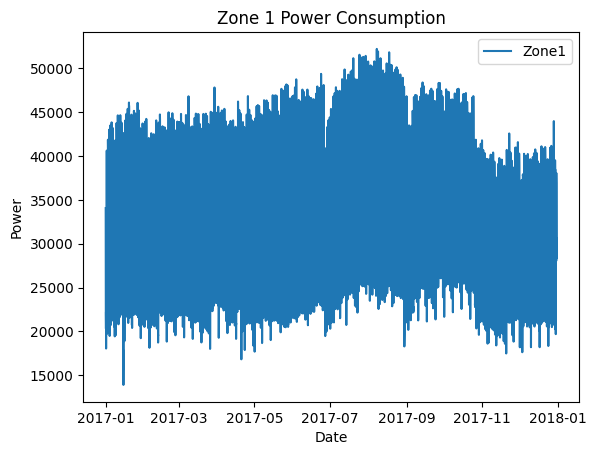

In [15]:
plt.Figure(figsize=(14,8))
plt.plot(df['PowerConsumption_Zone1'],label='Zone1')
plt.title('Zone 1 Power Consumption')
plt.xlabel('Date')
plt.ylabel('Power')
plt.legend()
plt.show()

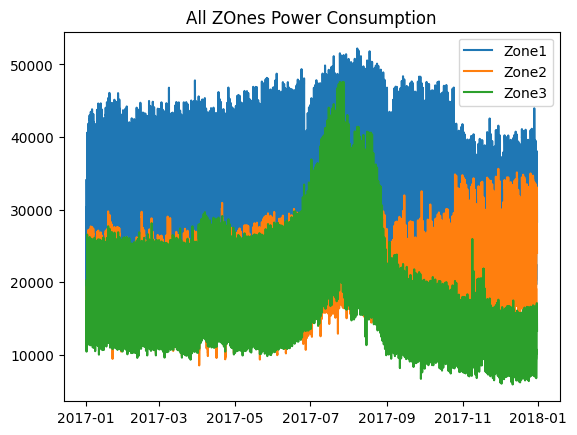

In [16]:
plt.Figure(figsize=(14,8))
plt.plot(df['PowerConsumption_Zone1'],label='Zone1')
plt.plot(df['PowerConsumption_Zone2'],label='Zone2')
plt.plot(df['PowerConsumption_Zone3'],label='Zone3')
plt.title('Zone 1 Power Consumption')
plt.legend()
plt.title('All ZOnes Power Consumption')
plt.show()

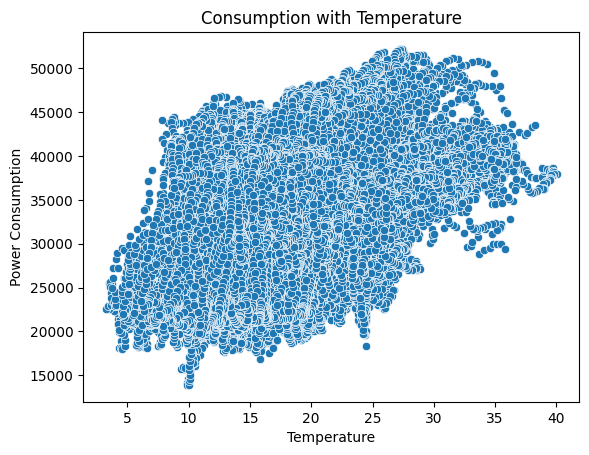

In [17]:
plt.title('Consumption with Temperature')
sns.scatterplot(data=df,x=df['Temperature'],y=df['PowerConsumption_Zone1'])
plt.xlabel('Temperature')
plt.ylabel('Power Consumption')
plt.show()

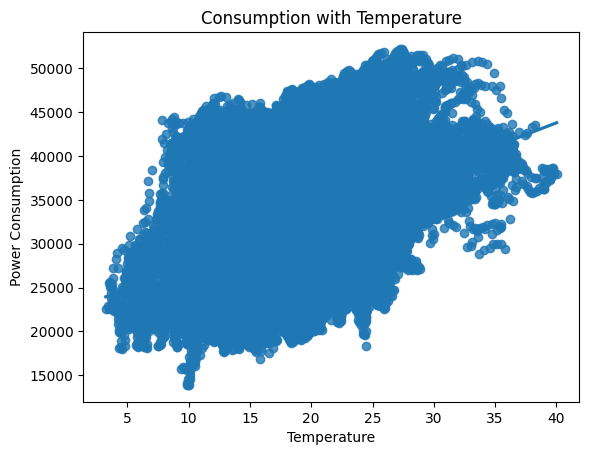

In [18]:
plt.title('Consumption with Temperature')
sns.regplot(data=df,x=df['Temperature'],y=df['PowerConsumption_Zone1'])
plt.xlabel('Temperature')
plt.ylabel('Power Consumption')
plt.show()

In [19]:
corr=df['Temperature'].corr(df['PowerConsumption_Zone1'])
print(corr)

0.4402207890291407


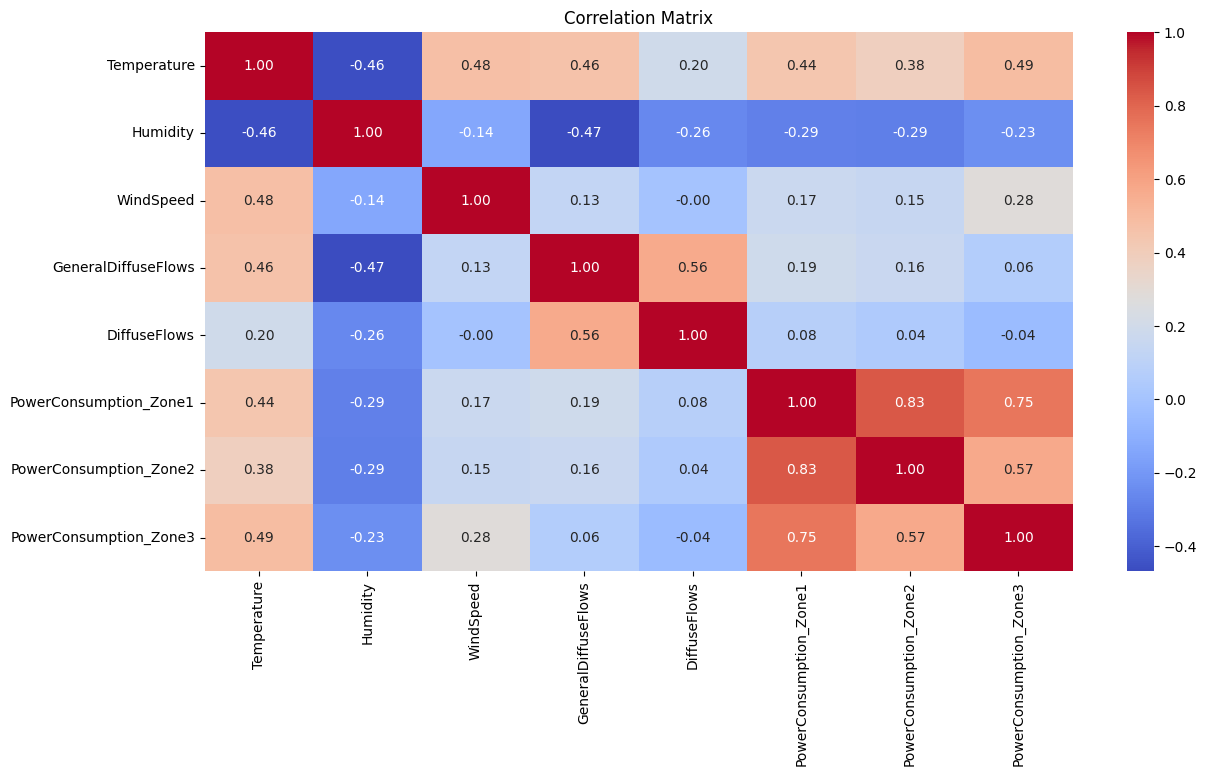

In [20]:
plt.figure(figsize=(14,7))
sns.heatmap(df.corr(numeric_only=True),annot=True,fmt=".2f",cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [21]:
df['hour']=df.index.hour
df['dayofweek']=df.index.dayofweek
df['month']=df.index.month
df['is_weekend']=(df['dayofweek'] >= 5).astype(int)

In [22]:
df.head()

,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3,hour,dayofweek,month,is_weekend
Datetime,,,,,,,,,,,,
2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386,0,6,1,1
2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434,0,6,1,1
2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373,0,6,1,1
2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711,0,6,1,1
2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964,0,6,1,1


In [23]:
df=df.drop(columns=['PowerConsumption_Zone2','PowerConsumption_Zone3'])

In [24]:
df.shape

(52416, 10)

In [25]:
df.head()

,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,hour,dayofweek,month,is_weekend
Datetime,,,,,,,,,,
2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,0,6,1,1
2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,0,6,1,1
2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,0,6,1,1
2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,0,6,1,1
2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,0,6,1,1


In [26]:
df['Zone1_MA144']=df['PowerConsumption_Zone1'].rolling(window=144).mean()
#144=24 days worth of 10 min intervals
df['Zone1_MA1008']=df['PowerConsumption_Zone1'].rolling(window=1008).mean()
#1008 = 7 days worth of 10 min intervals

In [27]:
df.dropna(inplace=True)
df.reset_index(drop=False,inplace=True)
print(df.shape)
df.head()

(51409, 13)


,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,hour,dayofweek,month,is_weekend,Zone1_MA144,Zone1_MA1008
0,2017-01-07 23:50:00,13.89,78.3,0.081,0.073,0.111,29401.51899,23,5,1,1,30612.700422,30102.121760
1,2017-01-08 00:00:00,14.07,78.2,0.081,0.048,0.130,28332.15190,0,6,1,1,30608.565401,30096.443641
2,2017-01-08 00:10:00,14.19,77.8,0.085,0.044,0.111,27791.39241,0,6,1,1,30606.751055,30094.436407
3,2017-01-08 00:20:00,14.27,77.7,0.087,0.033,0.122,26831.39241,0,6,1,1,30604.050633,30092.157926
4,2017-01-08 00:30:00,14.34,77.7,0.092,0.055,0.134,26296.70886,0,6,1,1,30600.337552,30090.241109


In [28]:
df.isnull().sum()

Datetime                  0
Temperature               0
Humidity                  0
WindSpeed                 0
GeneralDiffuseFlows       0
DiffuseFlows              0
PowerConsumption_Zone1    0
hour                      0
dayofweek                 0
month                     0
is_weekend                0
Zone1_MA144               0
Zone1_MA1008              0
dtype: int64

In [29]:
target_col='PowerConsumption_Zone1'
features=[
    'PowerConsumption_Zone1',
    'Temperature',
    'Humidity',
    'WindSpeed',
    'GeneralDiffuseFlows',
    'DiffuseFlows',
    'hour',
    'dayofweek',
    'month',
    'is_weekend',
    'Zone1_MA144',
    'Zone1_MA1008'
]

In [30]:
data=df[features].values
close_idx=features.index(target_col)

In [31]:
print(data.shape)

(51409, 12)


In [32]:
print(close_idx)

0


In [33]:
train_size=int(len(data) * 0.8)
train_data=data[:train_size]
test_data=data[train_size:]


In [34]:
print(train_data.shape)
print(test_data.shape)

(41127, 12)
(10282, 12)


In [35]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
train_scaled=scaler.fit_transform(train_data)
test_scaled=scaler.transform(test_data)

In [36]:
print(train_scaled.shape)

(41127, 12)


In [37]:
print(test_scaled.shape)

(10282, 12)


In [38]:
def create_sequence(dataset,target,window=144):
    X,y=[],[]
    for i in range(window,len(dataset)):
        X.append(dataset[i-window:i])
        y.append(dataset[i,target])
    return np.array(X),np.array(y)

WINDOW=144

X_train,y_train=create_sequence(train_scaled,close_idx,WINDOW)
X_test,y_test=create_sequence(test_scaled,close_idx,WINDOW)


In [39]:
print(X_train.shape)

(40983, 144, 12)


In [40]:
print(X_test.shape)

(10138, 144, 12)


# Now building the lstm model

In [41]:
n_features=X_train.shape[2]

from tensorflow.keras.layers import Dense,Dropout,LSTM
from tensorflow.keras.models import Sequential


In [42]:
model=Sequential([
    LSTM(128,return_sequences=True),
    Dropout(0.2),
    LSTM(64,return_sequences=False),
    Dropout(0.3),
    Dense(25,activation='relu'),
    Dense(1)
])

In [43]:
model.compile(optimizer='adam',loss='mse')
model.build(input_shape=(None,WINDOW,n_features))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 144, 128)       │        72,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 144, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,251 (481.45 KB)

 Trainable params: 123,251 (481.45 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
history=model.fit(X_train,y_train,epochs=20,batch_size=64,validation_data=(X_test,y_test),verbose=1)

Epoch 1/20
641/641 ━━━━━━━━━━━━━━━━━━━━ 146s 223ms/step - loss: 0.0087 - val_loss: 0.0017
Epoch 2/20
641/641 ━━━━━━━━━━━━━━━━━━━━ 171s 266ms/step - loss: 0.0023 - val_loss: 0.0012
Epoch 3/20
641/641 ━━━━━━━━━━━━━━━━━━━━ 187s 291ms/step - loss: 0.0013 - val_loss: 6.1420e-04
Epoch 4/20
641/641 ━━━━━━━━━━━━━━━━━━━━ 186s 290ms/step - loss: 9.1127e-04 - val_loss: 5.5974e-04
Epoch 5/20
641/641 ━━━━━━━━━━━━━━━━━━━━ 127s 198ms/step - loss: 7.0106e-04 - val_loss: 7.4811e-04
Epoch 6/20
641/641 ━━━━━━━━━━━━━━━━━━━━ 128s 200ms/step - loss: 5.8855e-04 - val_loss: 7.6480e-04
Epoch 7/20
641/641 ━━━━━━━━━━━━━━━━━━━━ 126s 197ms/step - loss: 5.1335e-04 - val_loss: 0.0010
Epoch 8/20
641/641 ━━━━━━━━━━━━━━━━━━━━ 126s 196ms/step - loss: 4.7128e-04 - val_loss: 4.4317e-04
Epoch 9/20
641/641 ━━━━━━━━━━━━━━━━━━━━ 124s 194ms/step - loss: 4.1659e-04 - val_loss: 6.8369e-04
Epoch 10/20
641/641 ━━━━━━━━━━━━━━━━━━━━ 126s 197ms/step - loss: 3.9169e-04 - val_loss: 3.5432e-04
Epoch 11/20
641/641 ━━━━━━━━━━━━━━━━━━━━ 11

In [45]:
pred=model.predict(X_test).flatten()


317/317 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step


In [ ]:
dummy_test=np.zeros((len(y_test),n_features))
dummy_test[:,close_idx]=y_test
y_test_actual=scaler.inverse_transform(dummy_test)[:,close_idx]

In [48]:
dummy_pred=np.zeros((len(pred),n_features))
dummy_pred[:,close_idx]=pred
y_pred_actual=scaler.inverse_transform(dummy_pred)[:,close_idx]

In [49]:
from sklearn.metrics import mean_squared_error,mean_absolute_error
rmse=np.sqrt(mean_squared_error(y_test_actual,y_pred_actual))
mae=(mean_absolute_error(y_test_actual,y_pred_actual))

In [50]:
print(rmse)
print(mae)

1036.7549270567486
824.015799750776


In [54]:
print('POwer Consumption range in dataset ',df['PowerConsumption_Zone1'].min(),df['PowerConsumption_Zone1'].max())
print(df['PowerConsumption_Zone1'].mean())

POwer Consumption range in dataset  13895.6962 52204.39512
32388.889880094925


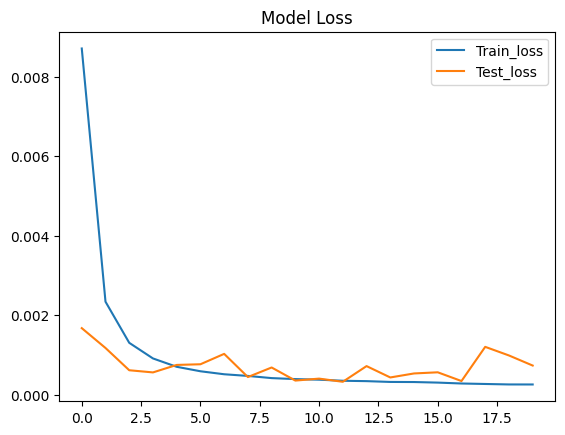

In [52]:
## Plotting the training
plt.plot(history.history['loss'],label='Train_loss')
plt.plot(history.history['val_loss'],label='Test_loss')
plt.legend()
plt.title('Model Loss')
plt.show()

In [55]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test_actual, y_pred_actual)
print("R² Score:", r2)

R² Score: 0.9714271955717785


In [56]:
import pickle
pickle.dump(scaler,open('scaler.pkl','wb'))
pickle.dump(close_idx,open('closeidx.pkl','wb'))
pickle.dump(features,open('features.pkl','wb'))
model.save('power_lstm.h5')